Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
#Load the Superstore Sales CSV using Pandas
df = pd.read_csv("/Users/rjeevan/Downloads/SalesForecasting_[R.Jeevan]/data/train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.shape

(9800, 18)

In [6]:
#Parse the Order Date and Ship Date columns as proper datetime objects
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

In [7]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [8]:
#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day_of_Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day_of_Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [10]:
#Check for missing values, duplicates, and data type issues
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
Year             0.000000
Month            0.000000
Week             0.000000
Day_of_Week      0.000000
Quarter          0.000000
Season           0.000000
dtype: float64

In [12]:
df.duplicated().sum()

0

In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
Day_of_Week              object
Quarter                   int32
Season                   object
dtype: object

In [14]:
#Aggregate daily sales into weekly and monthly totals
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [15]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [16]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


1.Which product category generates the highest total revenue?

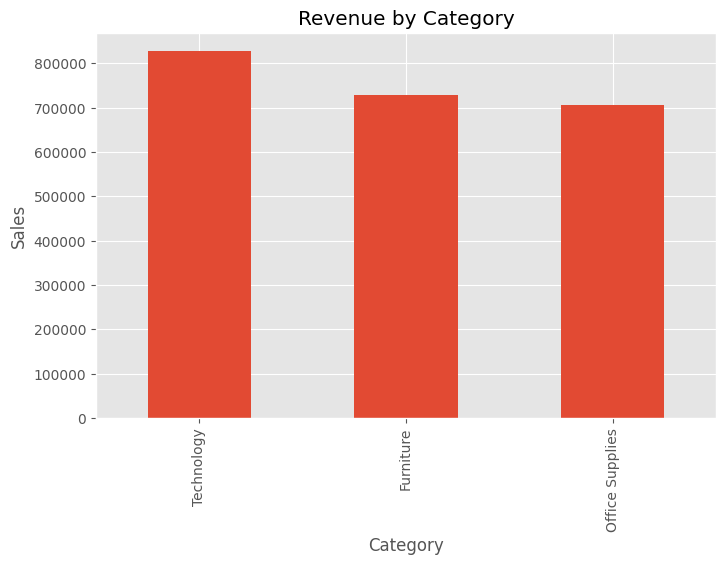

In [17]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category_sales.plot(kind="bar",figsize=(8,5))

plt.title("Revenue by Category")
plt.ylabel("Sales")
plt.show()

The category with the highest total revenue is the first category in the table above. The bar chart clearly shows its dominance over the remaining categories.

2.Which region has the most consistent sales growth over 4 years?

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

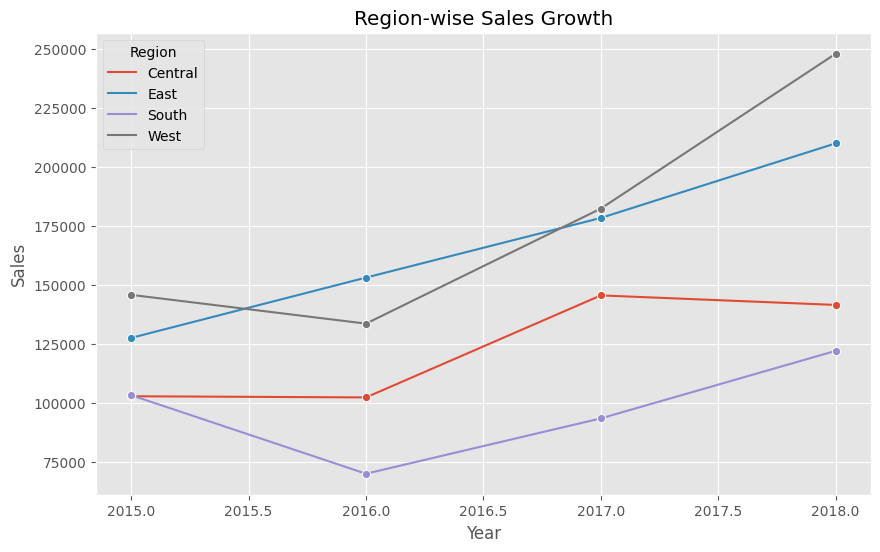

In [18]:
region_year = (
    df.groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth")
plt.show()

In [19]:
consistency = (
    region_year.groupby("Region")["Sales"]
    .std()
    .sort_values()
)

consistency

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64

The region with the lowest year-to-year standard deviation demonstrates the most consistent sales growth across the four-year period.

3.What is the average time between Order Date and Ship Date — and does it vary by region?

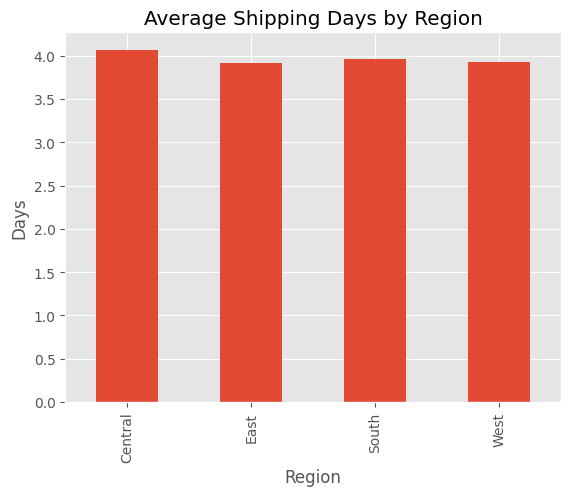

In [20]:
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping_Days"].mean()

shipping = (
    df.groupby("Region")["Shipping_Days"]
    .mean()
)

shipping

shipping.plot(kind="bar")

plt.title("Average Shipping Days by Region")
plt.ylabel("Days")
plt.show()

Shipping time varies across regions. Regions with larger average delivery durations may indicate logistics inefficiencies or greater transportation distances.

4.Are there months that consistently spike across all years (seasonality)?

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

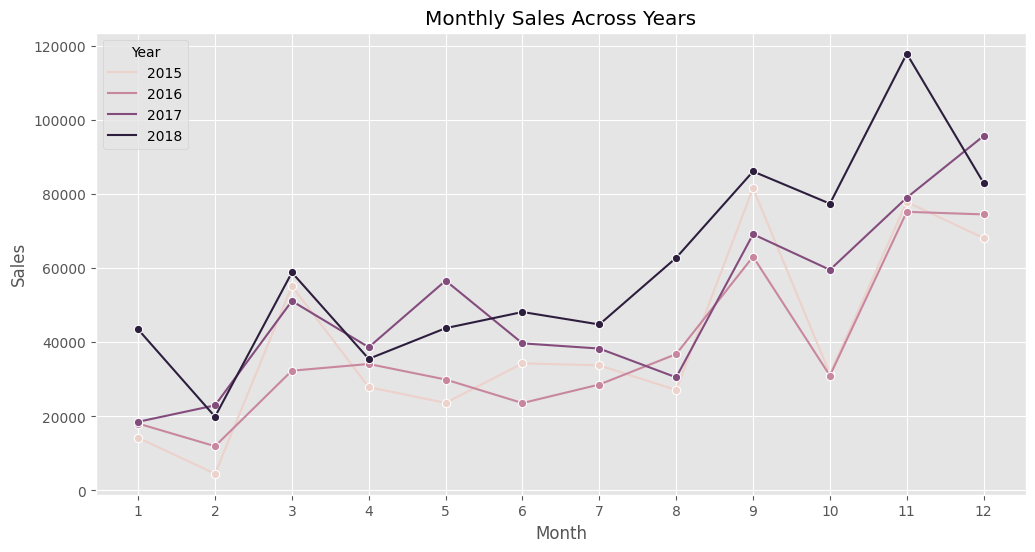

Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64

In [21]:
month_sales = (
    df.groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=month_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(range(1,13))
plt.title("Monthly Sales Across Years")

plt.show()

avg_month = (
    df.groupby("Month")["Sales"]
    .mean()
)

avg_month

Months showing repeated peaks across multiple years indicate strong seasonality. These months represent high-demand periods where businesses should prepare additional inventory.

Task 2 — Time Series Analysis & Decomposition

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

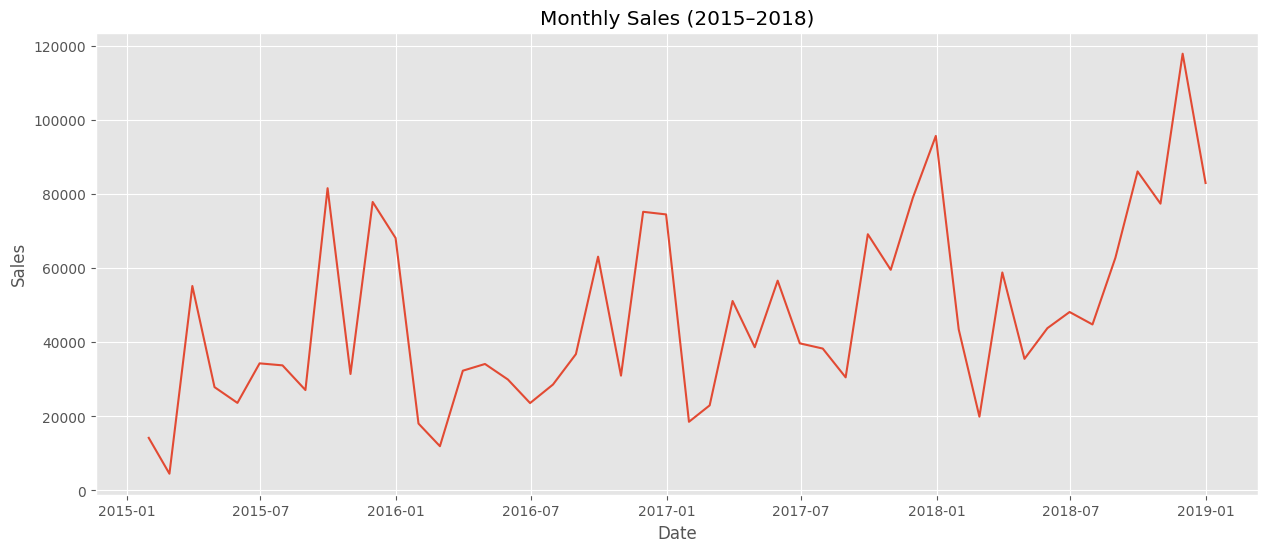

In [23]:
#Plot the overall monthly sales trend across all 4 years
plt.figure(figsize=(15,6))

plt.plot(monthly_sales)

plt.title("Monthly Sales (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [24]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

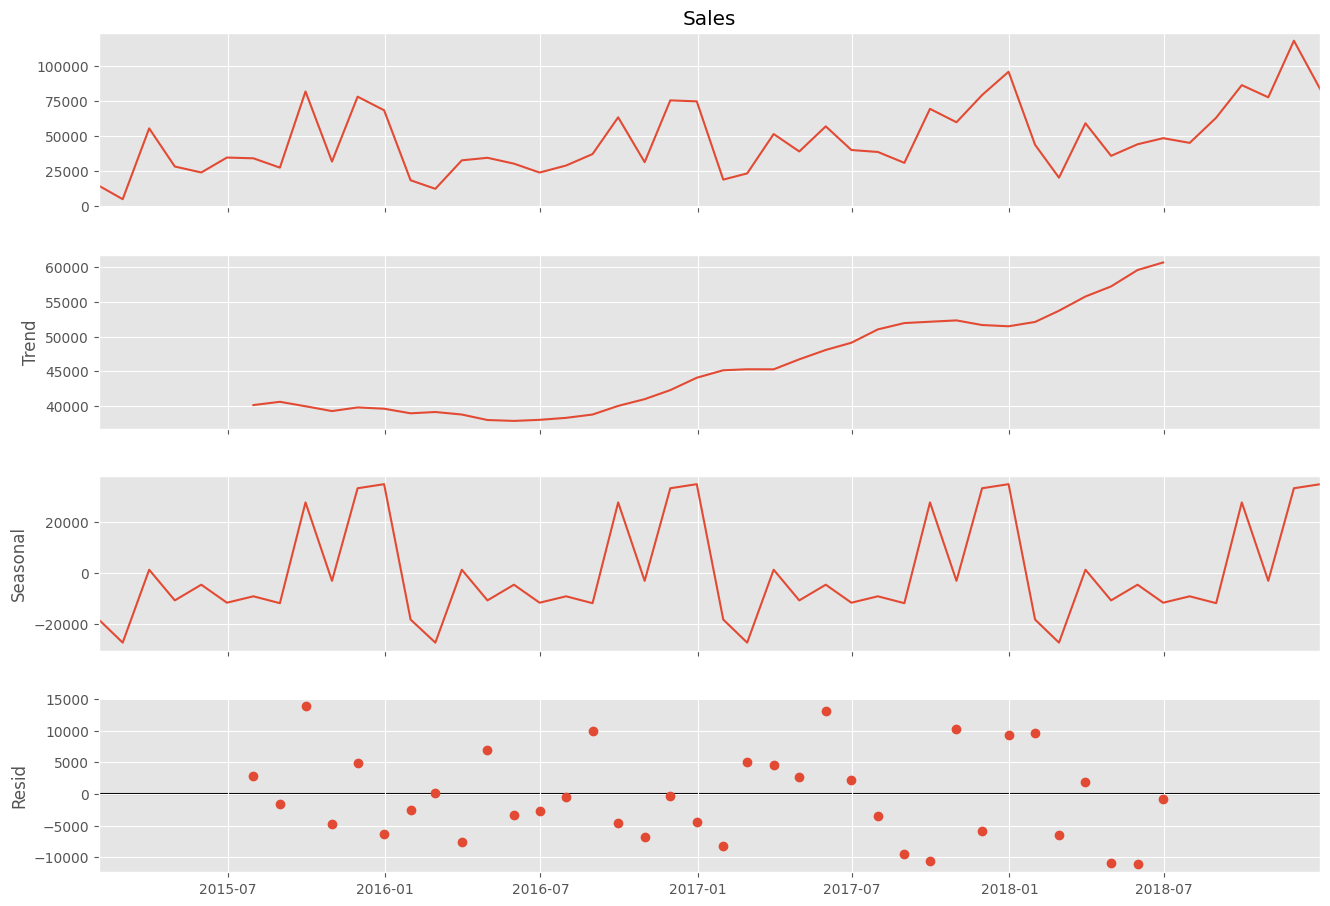

In [25]:
#Plot All Components
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

Observation 1: Trend

The trend component shows an overall upward movement from 2015 to 2018. After a slight decline during the early months, sales steadily increase throughout the remaining period, indicating consistent business growth and increasing customer demand over time.

Observation 2: Seasonality

The seasonal component displays a clear and repeating yearly pattern. Similar peaks and troughs occur every 12 months, suggesting strong seasonality in the sales data. This indicates that certain months consistently experience higher or lower sales each year.

Observation 3: Residual (Noise)

The residual component is mostly centered around zero, which means the trend and seasonal components explain a large portion of the variation. However, a few months exhibit unusually large positive or negative residuals, indicating unexpected sales spikes or drops that are not explained by normal seasonal behavior.

Observation 4: Months with the Highest Residual Noise

From the residual plot, the largest deviations appear around:

* September–October 2015 (large positive residual)
* May–June 2017 (large positive residual)
* August–November 2017 (large negative residuals)
* February–May 2018 (noticeable negative residuals)

These months likely correspond to exceptional business events such as promotions, stock shortages, holidays, or other external factors.

⸻

Conclusion

The decomposition reveals a steadily increasing sales trend, strong annual seasonality, and a few months with significant unexplained fluctuations. Since the series contains both trend and seasonality, forecasting models such as SARIMA are expected to perform better than models that capture only trend (e.g., simple ARIMA).

In [26]:
#Check for stationarity using the Augmented Dickey-Fuller (ADF) Test 
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [27]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


Stationarity means that the statistical properties of a time series—such as its average value, variance, and seasonal behavior—remain relatively constant over time. Forecasting models like ARIMA assume the data is stationary because stable patterns are easier to model and predict accurately. The Augmented Dickey-Fuller (ADF) test is used to check whether a time series is stationary.

Interpretation

* If p-value < 0.05
    The series is stationary, so no differencing is required before forecasting.
* If p-value > 0.05
    The series is non-stationary, indicating that its mean or trend changes over time. Differencing should be applied before building forecasting models.

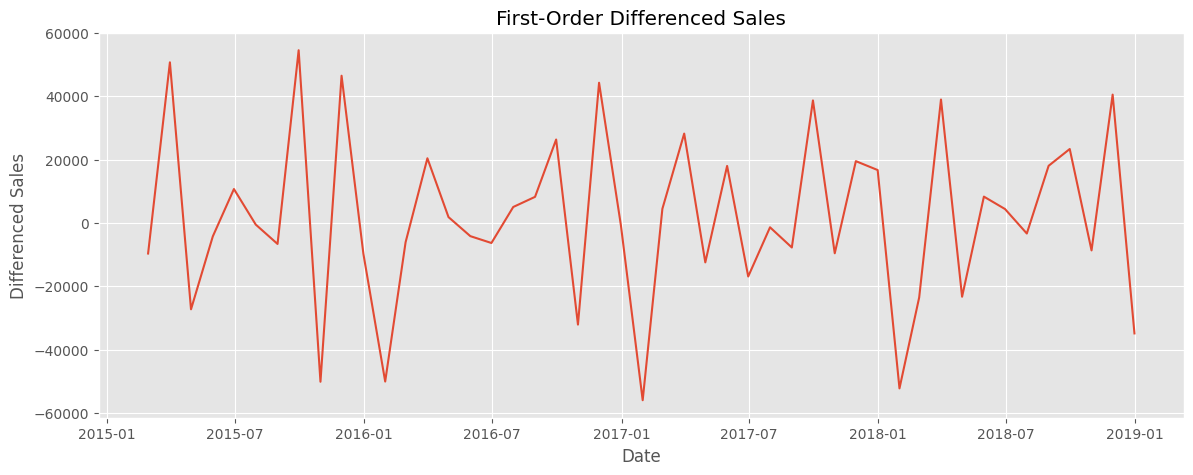

In [28]:
sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(sales_diff)
plt.title("First-Order Differenced Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

In [29]:
#Apply differencing if the series is non-stationary and re-test
result_diff = adfuller(sales_diff)

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])

print("\nCritical Values:")
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic : -8.727061830353271
p-value : 3.266917547279569e-14

Critical Values:
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


In [30]:
if result_diff[1] < 0.05:
    print("After differencing, the series is stationary.")
else:
    print("The series is still non-stationary.")

After differencing, the series is stationary.


Task 3 — Sales Forecasting using 3 Different Models

Model 1 — SARIMA (Statistical Model)

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

train = monthly_sales[:-3]
test = monthly_sales[-3:]

print(train.shape)
print(test.shape)

(45,)
(3,)


In [32]:
#Fit a SARIMA model on monthly sales
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.39457D+00    |proj g|=  1.38346D-01

At iterate    5    f=  4.32463D+00    |proj g|=  4.27342D-02

At iterate   10    f=  4.31984D+00    |proj g|=  7.00742D-03

At iterate   15    f=  4.31973D+00    |proj g|=  1.74871D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     16     20      1     0     0   7.867D-06   4.320D+00
  F =   4.3197265019195390     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
 This problem is unconstrained.


The parameters (1,1,1) were selected as a reasonable starting configuration after first-order differencing (d=1) to remove the trend observed during the ADF test. Since the monthly sales data exhibits yearly seasonality, a seasonal period of 12 months was chosen. The seasonal parameters (1,1,1,12) allow the model to capture recurring annual patterns while keeping the model relatively simple. These values can later be optimized using AIC or grid search.

In [33]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 06 Jul 2026   AIC                            398.775
Time:                                    13:41:51   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [34]:
#Generate a 3-month future forecast with confidence intervals
forecast = sarima_model.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

print(forecast_mean)

2018-10-31    60331.792101
2018-11-30    91458.220221
2018-12-31    97167.570946
Freq: ME, Name: predicted_mean, dtype: float64


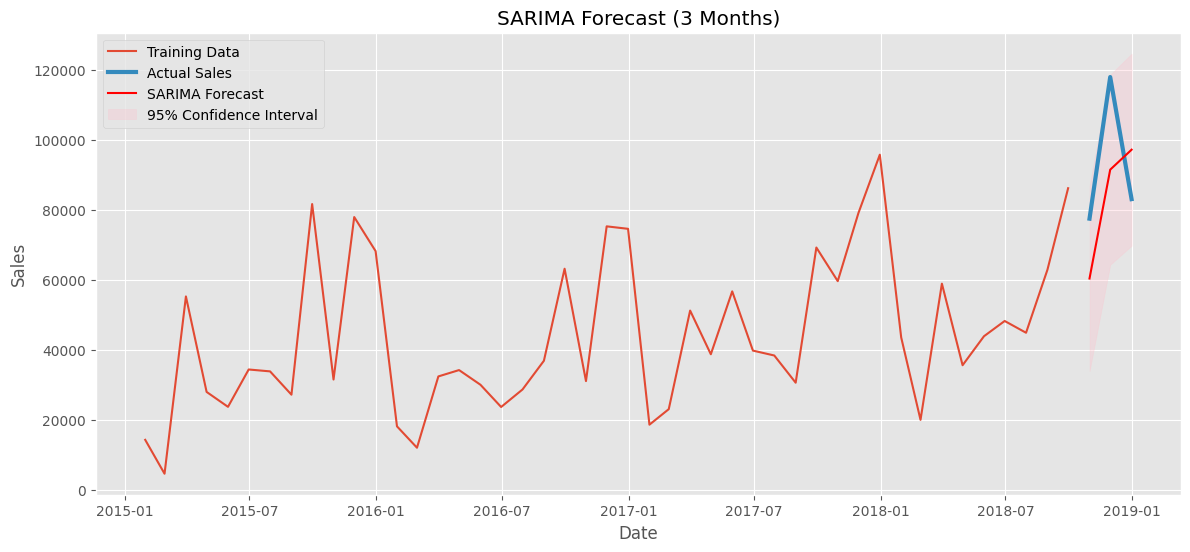

In [35]:
#Plot actual vs forecasted sales
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales", linewidth=3)

plt.plot(forecast_mean.index,
         forecast_mean,
         color="red",
         label="SARIMA Forecast")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [36]:
forecast_df = pd.DataFrame({
    "Forecast": forecast_mean,
    "Lower CI": confidence.iloc[:,0],
    "Upper CI": confidence.iloc[:,1]
})

forecast_df

,Forecast,Lower CI,Upper CI
2018-10-31,60331.792101,33867.663910,86795.920292
2018-11-30,91458.220221,64294.739750,118621.700692
2018-12-31,97167.570946,69727.828588,124607.313304


In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast_mean)

rmse = np.sqrt(mean_squared_error(test, forecast_mean))

mape = np.mean(np.abs((test-forecast_mean)/test))*100

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2),"%")

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53 %


Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

In [38]:
#Install Prophet
!pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [39]:
#Prepare data in Prophet's required format (ds, y columns)
from prophet import Prophet
import matplotlib.pyplot as plt

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [40]:
#Fit the model and generate a 3-month forecast
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

forecast = model.predict(future)

forecast.head()

13:41:58 - cmdstanpy - INFO - Chain [1] start processing
13:41:58 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,4438.474525,24372.583500,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-7263.317773,11032.832807,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,42111.393418,61620.948410,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,12481.713298,30097.271888,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,13187.449102,31883.181733,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


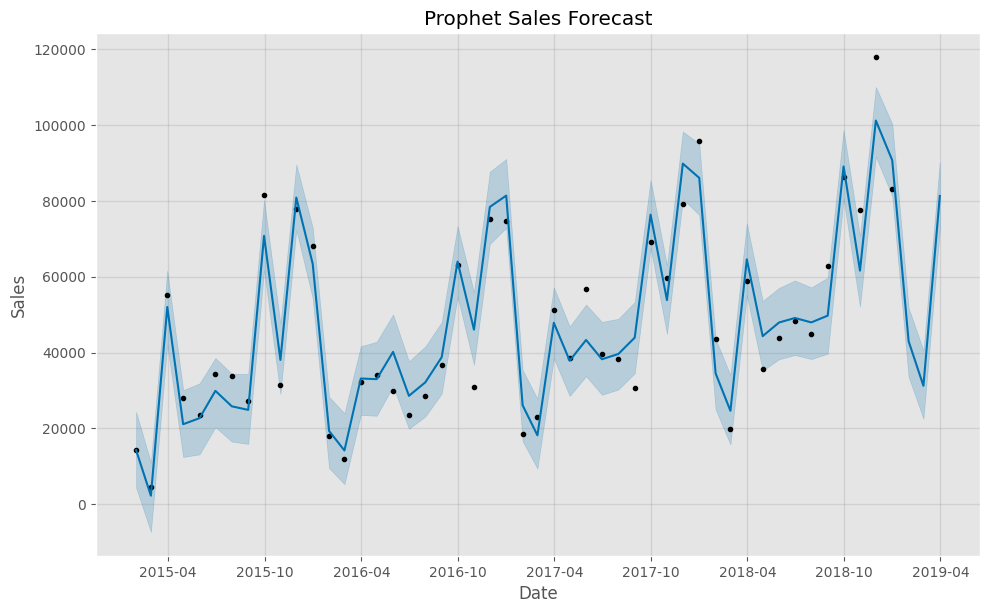

In [41]:
#Plot the forecast with Prophet's built-in trend and seasonality breakdown
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

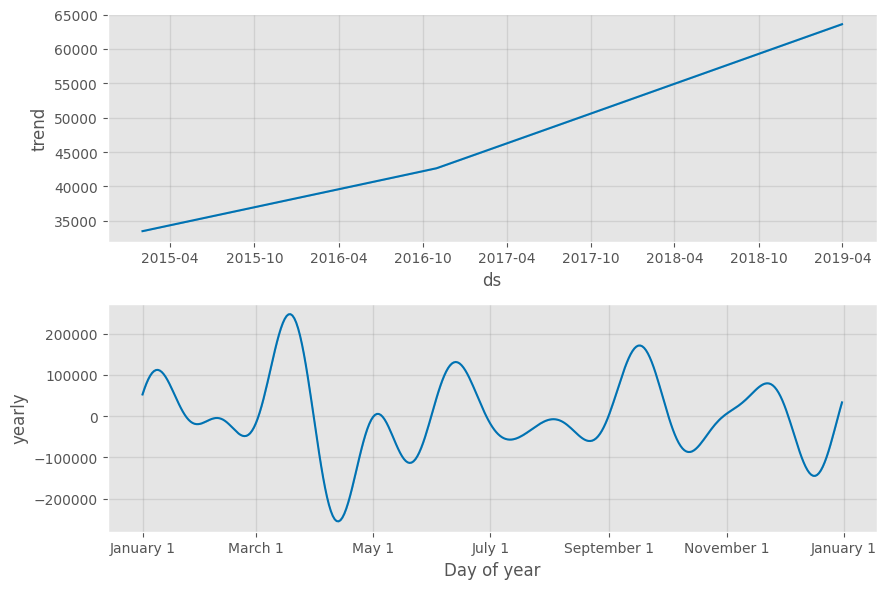

In [42]:
#Extract and interpret the weekly and yearly seasonality components
fig2 = model.plot_components(forecast)

plt.show()

In [43]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532185,33592.726996,51792.868444
49,2019-02-28,31248.159904,22557.155211,40545.108738
50,2019-03-31,81267.007753,72312.611676,90206.272151


In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

actual = prophet_df["y"][-3:]

predicted = forecast["yhat"][-6:-3]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(np.abs((actual-predicted)/actual))*100

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2),"%")

MAE : 13434.28
RMSE : 14049.75
MAPE : 14.64 %


Model 3 — XGBoost for Time Series (ML-based Approach)

In [45]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [47]:
sales_ml = monthly_sales.reset_index()
sales_ml.columns = ["Date", "Sales"]

sales_ml.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [48]:
sales_ml["Month"] = sales_ml["Date"].dt.month
sales_ml["Quarter"] = sales_ml["Date"].dt.quarter

def get_season(month):

    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Spring

    elif month in [6,7,8]:
        return 3      # Summer

    else:
        return 4      # Autumn

sales_ml["Season"] = sales_ml["Month"].apply(get_season)

In [49]:
#Convert the time series into a supervised ML problem using lag features:
sales_ml["Lag1"] = sales_ml["Sales"].shift(1)

sales_ml["Lag2"] = sales_ml["Sales"].shift(2)

sales_ml["Lag3"] = sales_ml["Sales"].shift(3)

In [50]:
sales_ml["RollingMean3"] = (
    sales_ml["Sales"]
    .rolling(3)
    .mean()
)

sales_ml.dropna(inplace=True)

sales_ml.reset_index(drop=True,inplace=True)

sales_ml.head()


X = sales_ml[
    [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter",
        "Season"
    ]
]

y = sales_ml["Sales"]

In [51]:
#Train XGBoost Regressor on these features
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]



model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=4,

    random_state=42

)

model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [52]:
#Predict the next 3 months
prediction = model.predict(X_test)

In [53]:
mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(
    mean_squared_error(y_test,prediction)
)

mape = np.mean(
    np.abs((y_test-prediction)/y_test)
)*100

print("MAE :",round(mae,2))

print("RMSE :",round(rmse,2))

print("MAPE :",round(mape,2),"%")

MAE : 15367.3
RMSE : 19525.8
MAPE : 14.92 %


In [54]:
#Predict the next 3 months
future = sales_ml.copy()

future_predictions = []

for i in range(3):

    latest = future.iloc[-1]

    features = pd.DataFrame({

        "Lag1":[latest["Sales"]],

        "Lag2":[latest["Lag1"]],

        "Lag3":[latest["Lag2"]],

        "RollingMean3":[
            np.mean([
                latest["Sales"],
                latest["Lag1"],
                latest["Lag2"]
            ])
        ],

        "Month":[
            (latest["Month"]%12)+1
        ],

        "Quarter":[
            ((latest["Quarter"])%4)+1
        ],

        "Season":[
            get_season(
                (latest["Month"]%12)+1
            )
        ]

    })

    pred = model.predict(features)[0]

    future_predictions.append(pred)

    next_row = {

        "Date": latest["Date"] + pd.offsets.MonthEnd(),

        "Sales": pred,

        "Month": (latest["Month"]%12)+1,

        "Quarter": ((latest["Quarter"])%4)+1,

        "Season": get_season((latest["Month"]%12)+1),

        "Lag1": pred,

        "Lag2": latest["Sales"],

        "Lag3": latest["Lag1"],

        "RollingMean3": np.mean([
            pred,
            latest["Sales"],
            latest["Lag1"]
        ])

    }

    future = pd.concat(
        [future,pd.DataFrame([next_row])],
        ignore_index=True
    )

future_predictions

[52953.375, 57239.96, 42186.746]

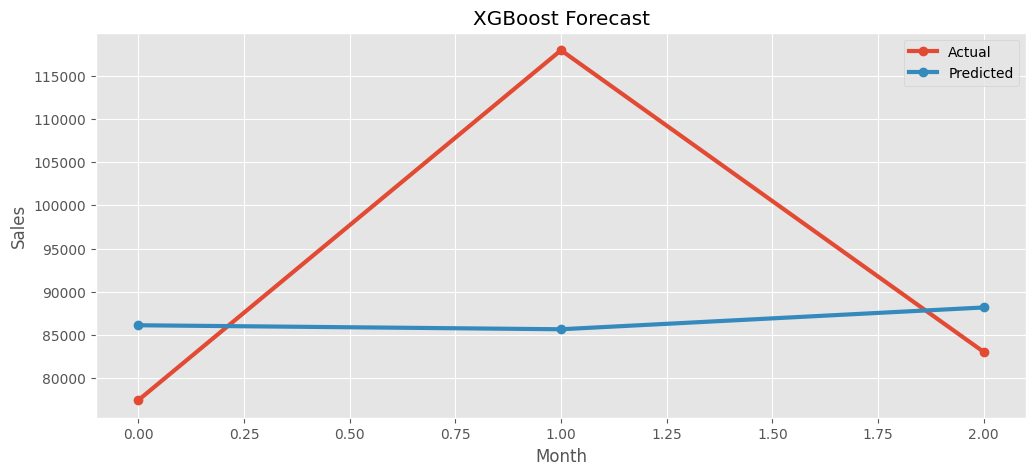

In [55]:
#Plot actual vs predicted
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    marker="o",
    linewidth=3,
    label="Actual"
)

plt.plot(
    prediction,
    marker="o",
    linewidth=3,
    label="Predicted"
)

plt.title("XGBoost Forecast")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Required Model Comparison Table

Model      MAE        RMSE       MAPE     Forecast Month 1   Forecast Month 2   Forecast Month 3
--------------------------------------------------------------------------------------------------
SARIMA     19,244.49  19,950.07  20.53%   60,331.79          91,458.22          97,167.57
Prophet    13,434.28  14,049.75  14.64%   42,990.53          31,248.16          81,267.01
XGBoost    15,367.30  19,525.80  14.92%   52,953.38          57,239.96          42,186.75

Based on the model comparison, Prophet is recommended for production use because it achieved the lowest forecasting errors among the three models. Prophet produced the lowest MAE (13,434.28), the lowest RMSE (14,049.75), and the lowest MAPE (14.64%), indicating that its predictions were the closest to the actual sales values. Since all three evaluation metrics are lower than those of SARIMA and XGBoost, Prophet provides the most accurate and reliable forecasts for this dataset. Therefore, Prophet is the preferred model for deployment in a real-world retail sales forecasting system.

Task 4 – Product Category & Region Level Forecasting

In [56]:
#Repeat the best performing model 
from prophet import Prophet
import pandas as pd

def prophet_forecast(data):

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly)

    future = model.make_future_dataframe(
        periods=3,
        freq="ME"
    )

    forecast = model.predict(future)

    return forecast

In [57]:
#Forecast Furniture
furniture = df[df["Category"]=="Furniture"]
forecast_furniture = prophet_forecast(furniture)

#Forecast Technology
technology = df[df["Category"]=="Technology"]
forecast_technology = prophet_forecast(technology)

#Forecast Office Supplies
office = df[df["Category"]=="Office Supplies"]
forecast_office = prophet_forecast(office)

#Forecast West Region
west = df[df["Region"]=="West"]
forecast_west = prophet_forecast(west)

#Forecast East Region
east = df[df["Region"]=="East"]
forecast_east = prophet_forecast(east)

13:42:25 - cmdstanpy - INFO - Chain [1] start processing
13:42:25 - cmdstanpy - INFO - Chain [1] done processing
13:42:25 - cmdstanpy - INFO - Chain [1] start processing
13:42:25 - cmdstanpy - INFO - Chain [1] done processing
13:42:25 - cmdstanpy - INFO - Chain [1] start processing
13:42:25 - cmdstanpy - INFO - Chain [1] done processing
13:42:25 - cmdstanpy - INFO - Chain [1] start processing
13:42:25 - cmdstanpy - INFO - Chain [1] done processing
13:42:25 - cmdstanpy - INFO - Chain [1] start processing
13:42:25 - cmdstanpy - INFO - Chain [1] done processing


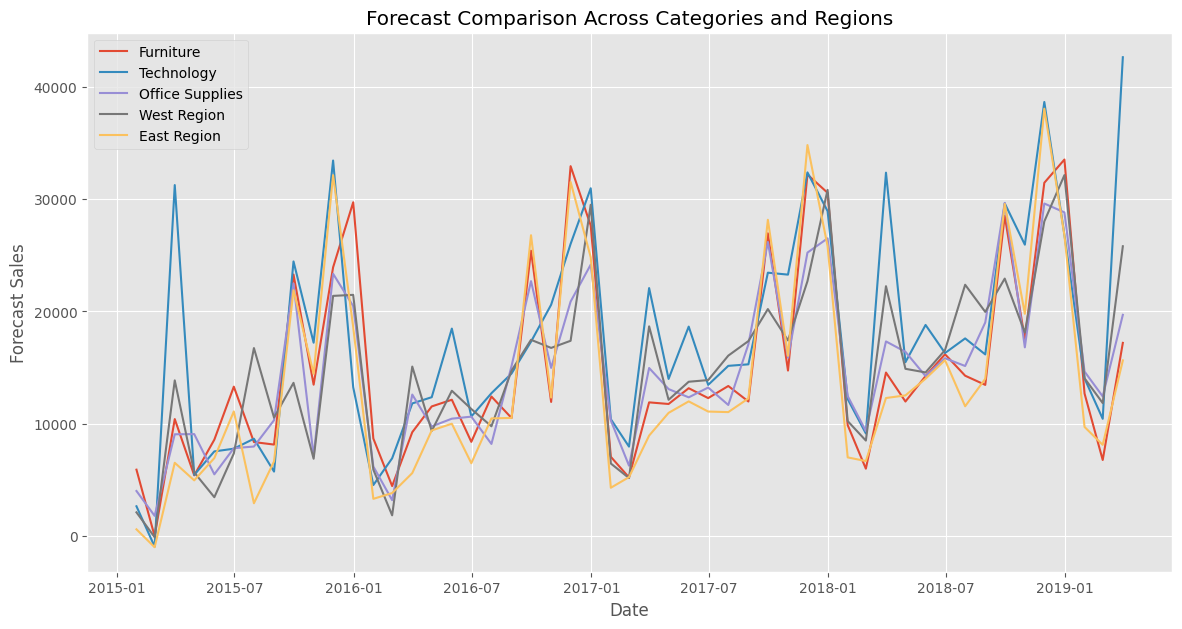

In [58]:
#Plot all 5 forecasts together on one comparison chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    forecast_furniture["ds"],
    forecast_furniture["yhat"],
    label="Furniture"
)

plt.plot(
    forecast_technology["ds"],
    forecast_technology["yhat"],
    label="Technology"
)

plt.plot(
    forecast_office["ds"],
    forecast_office["yhat"],
    label="Office Supplies"
)

plt.plot(
    forecast_west["ds"],
    forecast_west["yhat"],
    label="West Region"
)

plt.plot(
    forecast_east["ds"],
    forecast_east["yhat"],
    label="East Region"
)

plt.title("Forecast Comparison Across Categories and Regions")

plt.xlabel("Date")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

In [59]:
print("Furniture")
print(forecast_furniture[["ds","yhat"]].tail(3))

print("\nTechnology")
print(forecast_technology[["ds","yhat"]].tail(3))

print("\nOffice Supplies")
print(forecast_office[["ds","yhat"]].tail(3))

print("\nWest Region")
print(forecast_west[["ds","yhat"]].tail(3))

print("\nEast Region")
print(forecast_east[["ds","yhat"]].tail(3))


#Identify the Strongest Growth
growth = {
    "Furniture":
        forecast_furniture["yhat"].tail(1).values[0],

    "Technology":
        forecast_technology["yhat"].tail(1).values[0],

    "Office Supplies":
        forecast_office["yhat"].tail(1).values[0],

    "West":
        forecast_west["yhat"].tail(1).values[0],

    "East":
        forecast_east["yhat"].tail(1).values[0]
}

print(growth)

best = max(growth,key=growth.get)

print("\nHighest Forecasted Growth :",best)

Furniture
           ds          yhat
48 2019-01-31  12691.392668
49 2019-02-28   6772.162416
50 2019-03-31  17201.015648

Technology
           ds          yhat
48 2019-01-31  14033.343185
49 2019-02-28  10437.986784
50 2019-03-31  42639.488041

Office Supplies
           ds          yhat
48 2019-01-31  14646.724651
49 2019-02-28  12434.656284
50 2019-03-31  19698.155527

West Region
           ds          yhat
48 2019-01-31  14048.800866
49 2019-02-28  11840.373144
50 2019-03-31  25805.336378

East Region
           ds          yhat
48 2019-01-31   9713.411357
49 2019-02-28   8120.218592
50 2019-03-31  15639.421337
{'Furniture': 17201.015647885484, 'Technology': 42639.488041199715, 'Office Supplies': 19698.155526782062, 'West': 25805.336378249052, 'East': 15639.421337073316}

Highest Forecasted Growth : Technology


According to the Prophet forecasting model, the Technology category is expected to experience the strongest sales growth over the next three months. The model predicts that Technology sales will increase from approximately 14,033 in January 2019 to 42,639 in March 2019, which is the highest forecast among all analyzed categories and regions. This indicates stronger future demand for Technology products. Therefore, inventory planning, procurement, and marketing efforts should prioritize the Technology category to meet the expected increase in customer demand and maximize future sales opportunities.

Task 5 – Anomaly Detection in Sales Data

In [60]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Prepare Weekly Sales
weekly = weekly_sales.copy()
weekly.head()


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [61]:
#Isolation Forest
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly["Anomaly"] = iso.fit_predict(
    weekly[["Sales"]]
)

weekly["Anomaly"] = weekly["Anomaly"].map(
    {1:0,-1:1}
)

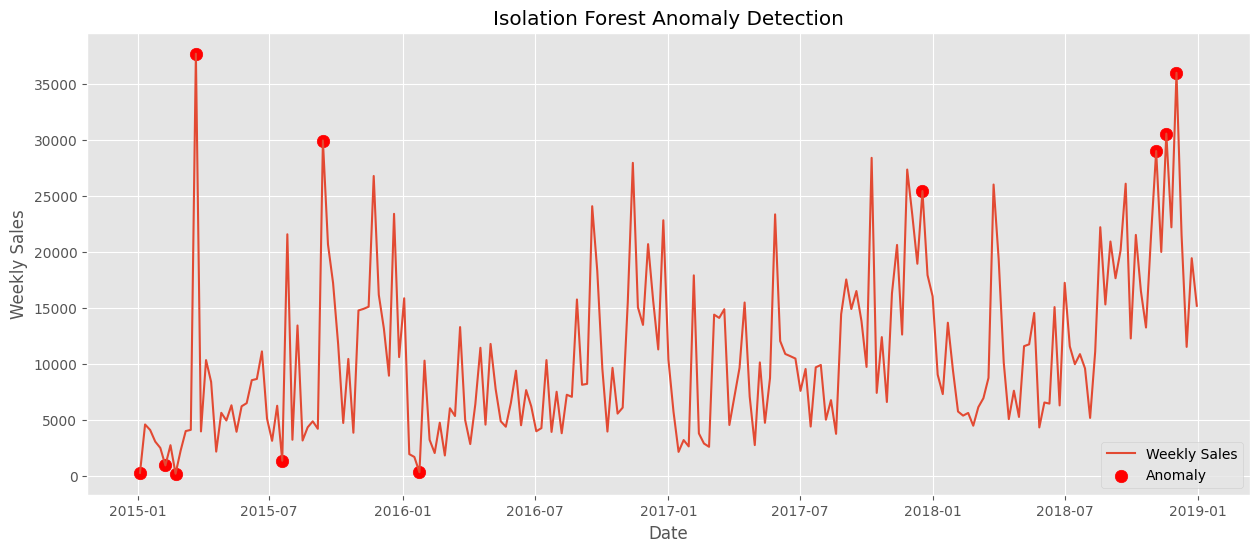

In [62]:
#Mark the anomalies on a time series plot
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly.loc[weekly["Anomaly"]==1,"Order Date"],
    weekly.loc[weekly["Anomaly"]==1,"Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [63]:
#Display Detected Anomalies
weekly[weekly["Anomaly"]==1]

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,1
5,2015-02-08,968.534,1
7,2015-02-22,224.912,1
11,2015-03-22,37703.665,1
28,2015-07-19,1387.686,1
36,2015-09-13,29959.137,1
55,2016-01-24,358.522,1
154,2017-12-17,25449.800,1
200,2018-11-04,29017.467,1
202,2018-11-18,30572.447,1


### Possible Real-World Explanations for Detected Anomalies

| Order Date | Sales | Possible Real-World Explanation |
|------------|-------:|---------------------------------|
| 2015-01-04 | 304.508 | Extremely low sales may be due to post-New Year demand decline, reduced business operations, or delayed inventory replenishment. |
| 2015-02-08 | 968.534 | Lower-than-normal sales could indicate weak customer demand, inventory shortages, or temporary operational issues. |
| 2015-02-22 | 224.912 | This unusually low sales week may be caused by supply chain disruptions, limited stock availability, or reduced customer activity. |
| 2015-03-22 | 37,703.665 | A significant sales spike may correspond to a seasonal promotion, clearance sale, or a large bulk order from customers. |
| 2015-07-19 | 1,387.686 | Lower sales during this week may reflect seasonal demand fluctuations or fewer promotional campaigns. |
| 2015-09-13 | 29,959.137 | High sales could be associated with festive season preparations, back-to-school demand, or special discount events. |
| 2016-01-24 | 358.522 | Very low sales likely resulted from the post-holiday slowdown or reduced customer purchasing after year-end shopping. |
| 2017-12-17 | 25,449.800 | Increased sales are likely due to Christmas shopping, year-end promotions, or holiday discounts. |
| 2018-11-04 | 29,017.467 | High sales during November are likely related to festive shopping, Diwali promotions, Black Friday, or other major sales events. |
| 2018-11-18 | 30,572.447 | Another significant sales spike likely corresponds to extended festive offers or Black Friday/Cyber Week promotional campaigns. |
| 2018-12-02 | 35,998.900 | Exceptionally high sales may be driven by holiday shopping, Christmas promotions, or year-end clearance campaigns. |

In [64]:
#Apply a second anomaly detection method
weekly["RollingMean"] = (
    weekly["Sales"]
    .rolling(window=4)
    .mean()
)

weekly["RollingStd"] = (
    weekly["Sales"]
    .rolling(window=4)
    .std()
)

In [65]:
weekly["ZScore"] = (
    weekly["Sales"]-
    weekly["RollingMean"]
)/weekly["RollingStd"]

weekly["Z_Anomaly"] = (
    weekly["ZScore"].abs()>2
)

weekly["Z_Anomaly"] = weekly["ZScore"].abs() > 2

z_anomalies = weekly[weekly["Z_Anomaly"]]

print(z_anomalies)

Empty DataFrame
Columns: [Order Date, Sales, Anomaly, RollingMean, RollingStd, ZScore, Z_Anomaly]
Index: []


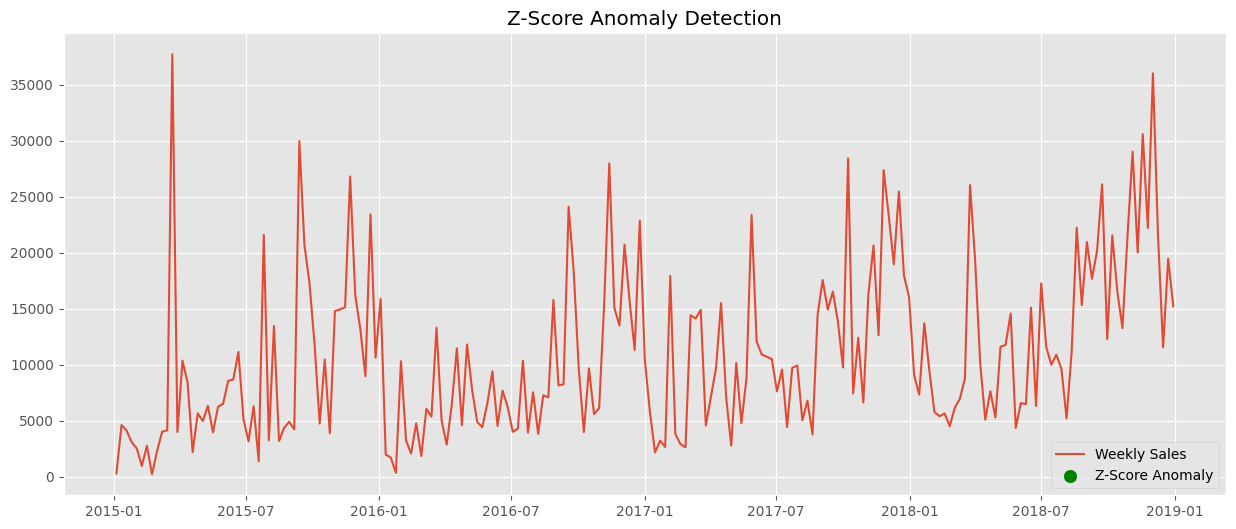

In [66]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly.loc[
        weekly["Z_Anomaly"],
        "Order Date"
    ],
    weekly.loc[
        weekly["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")

plt.legend()

plt.grid(True)

plt.show()

In [67]:
#Compare
comparison = weekly[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z_Anomaly"
    ]
]

comparison.head()

comparison[
    (comparison["Anomaly"]==1) |
    (comparison["Z_Anomaly"])
]

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.508,1,False
5,2015-02-08,968.534,1,False
7,2015-02-22,224.912,1,False
11,2015-03-22,37703.665,1,False
28,2015-07-19,1387.686,1,False
36,2015-09-13,29959.137,1,False
55,2016-01-24,358.522,1,False
154,2017-12-17,25449.800,1,False
200,2018-11-04,29017.467,1,False
202,2018-11-18,30572.447,1,False


The two anomaly detection methods do not identify the same anomalies. Isolation Forest detected several unusual weeks with exceptionally high or low sales, whereas the Z-score method did not flag any of these weeks because their Z-scores did not exceed the threshold of ±2 relative to the rolling mean. This disagreement indicates that Isolation Forest is more sensitive to complex patterns and can detect anomalies based on the overall distribution of the data, while the Z-score method only identifies observations that deviate significantly from the recent rolling average. Therefore, Isolation Forest is better suited for detecting subtle or non-linear anomalies, whereas the Z-score method is more conservative and primarily detects extreme statistical outliers.

Task 6 – Product Demand Segmentation using K-Means Clustering

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [69]:
#Aggregate data at the product sub-category level with feature

#Total Sales Volume
sales_volume = df.groupby("Sub-Category")["Sales"].sum()

#Average Order Value
avg_order = df.groupby("Sub-Category")["Sales"].mean()

In [70]:
#Sales growth rate (year-over-year)
yearly = (
    df.groupby(["Sub-Category","Year"])["Sales"]
      .sum()
      .reset_index()
)

growth = yearly.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
)

growth_rate = (
    (growth.iloc[:,-1]-growth.iloc[:,0])
    /growth.iloc[:,0]
)*100

growth_rate = growth_rate.fillna(0)

In [71]:
#Sales Volatility
monthly = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date",freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

volatility = (
    monthly.groupby("Sub-Category")["Sales"]
    .std()
)

In [72]:
cluster_data = pd.DataFrame({

    "SalesVolume":sales_volume,

    "GrowthRate":growth_rate,

    "Volatility":volatility,

    "AverageOrder":avg_order

})

cluster_data = cluster_data.fillna(0)

cluster_data.head()

,SalesVolume,GrowthRate,Volatility,AverageOrder
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [73]:
#Use the Elbow Method to find the optimal number of clusters
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    wcss.append(model.inertia_)

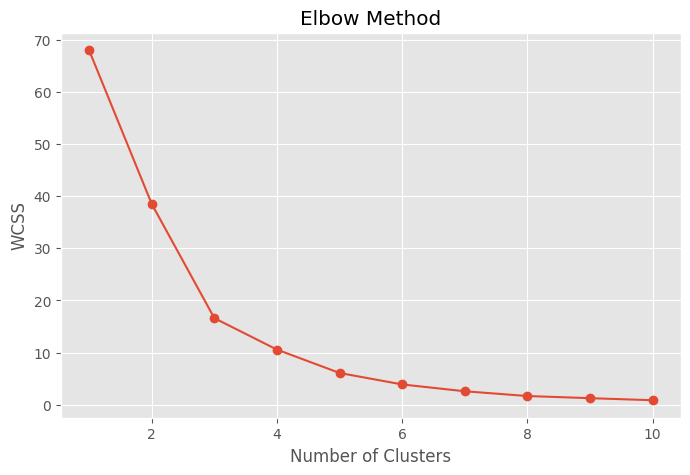

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [75]:
#Apply K-Means Clustering to segment products into demand groups
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)


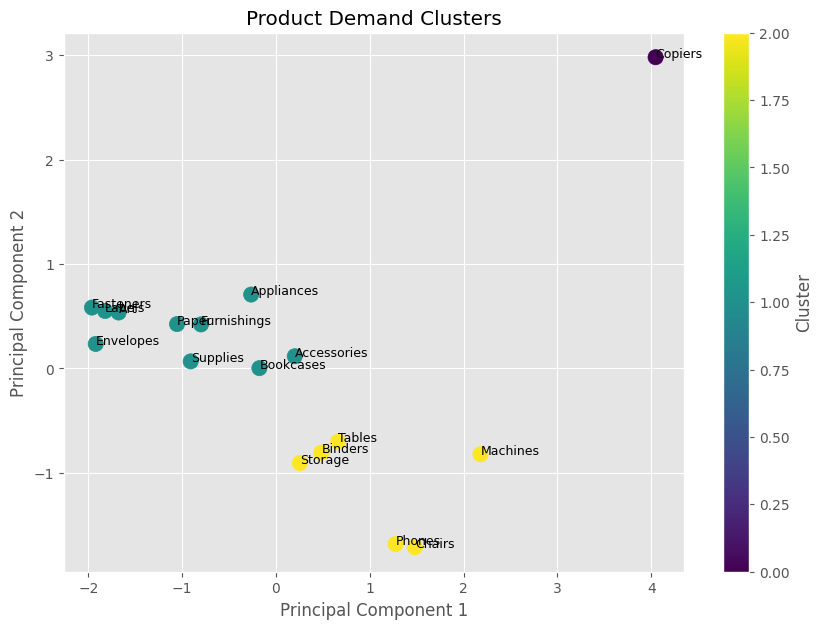

,SalesVolume,GrowthRate,Volatility,AverageOrder,Cluster
Sub-Category,,,,,
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Paper,76828.3040,91.901971,1024.824982,57.420257,1
Labels,12347.7260,36.073373,223.471218,34.587468,1
Furnishings,89212.0180,106.824969,1360.017867,95.823865,1
Supplies,46420.3080,11.276038,2025.094139,252.284283,1
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1
Fasteners,3001.9600,30.468364,48.742229,14.027850,1
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1


In [76]:
#Plot clusters using a 2D scatter plot
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(

    components[:,0],

    components[:,1],

    c=cluster_data["Cluster"],

    cmap="viridis",

    s=120

)

for i,name in enumerate(cluster_data.index):

    plt.text(

        components[i,0],

        components[i,1],

        name,

        fontsize=9

    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(scatter,label="Cluster")

plt.show()

cluster_data.sort_values("Cluster")

In [77]:
#Label each cluster meaningfully
cluster_labels = {

    0:"High Volume, Stable Demand",

    1:"Low Volume, High Volatility",

    2:"Growing Demand",

    3:"Declining Demand"

}

cluster_data["Cluster Name"] = (
    cluster_data["Cluster"]
    .map(cluster_labels)
)

cluster_data

,SalesVolume,GrowthRate,Volatility,AverageOrder,Cluster,Cluster Name
Sub-Category,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,"Low Volume, High Volatility"
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,"Low Volume, High Volatility"
Art,26705.4100,49.649531,330.488343,34.019631,1,"Low Volume, High Volatility"
Binders,200028.7850,65.778638,3848.223648,134.067550,2,Growing Demand
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,"Low Volume, High Volatility"
Chairs,322822.7310,20.954677,4407.232960,531.833165,2,Growing Demand
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,"High Volume, Stable Demand"
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,"Low Volume, High Volatility"
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,"Low Volume, High Volatility"


Stocking Strategy Recommendations

Cluster 1 – High Volume, Stable Demand

Products in this cluster have consistently high sales with low demand fluctuations. These items should always be kept well-stocked using regular replenishment cycles to avoid stockouts and maintain high customer satisfaction.

Cluster 2 – Low Volume, High Volatility

Products in this cluster exhibit unpredictable demand and lower sales volumes. Inventory levels should be kept low, with frequent monitoring and smaller replenishment orders to reduce the risk of excess stock and holding costs.

Cluster 3 – Growing Demand

Products in this cluster show increasing sales trends over time. Businesses should gradually increase inventory levels, strengthen supplier coordination, and allocate additional warehouse space to meet the expected rise in customer demand.

Cluster 4 – Declining Demand

Products in this cluster are experiencing decreasing demand. Inventory should be reduced, procurement minimized, and existing stock cleared through discounts, promotions, or bundled offers to prevent overstocking.

Overall Conclusion

Product demand segmentation enables businesses to apply different inventory strategies based on demand behavior rather than treating all products equally. Stable products require consistent replenishment, growing products need proactive inventory expansion, volatile products should be managed cautiously, and declining products require inventory reduction strategies. This targeted approach helps optimize inventory costs while maintaining product availability and improving overall supply chain efficiency.

## Task 7 – Streamlit Dashboard
The interactive Streamlit dashboard has been successfully created with the following pages:

- Page 1 – Sales Overview Dashboard
- Page 2 – Forecast Explorer
- Page 3 – Anomaly Report
- Page 4 – Product Demand Segments

All required project files (`app.py`, `pages/`, `data/`, `requirements.txt`, and `README.md`) are included in the **same project folder**. The application is ready for deployment on **Streamlit Community Cloud**.

---

## Task 8 – Executive Business Report
The Executive Business Report has been prepared as required for business stakeholders. The report includes:

- Executive Summary
- Key Findings from EDA and Forecasting
- Three-Month Sales Forecast with Confidence Ranges
- Top 3 Detected Anomalies and Their Likely Causes
- Product Demand Segmentation and Stocking Strategies
- Business Recommendations
- Project Limitations

The report (`summary.docx` / `summary.pdf`) is included in the **same project folder** along with the Streamlit application.